# Customer Lifetime Value (CLV) Prediction using Machine Learning

## 📌 Business Context

Customer Lifetime Value (CLV) is a key business metric that estimates the future revenue a customer is expected to generate over a given period. Accurate CLV prediction enables organizations to identify high-value customers, optimize marketing investments, improve customer retention strategies, and support long-term business growth.

## 🎯 Project Objective

The objective of this project is to develop a machine learning model that predicts the next **90-day Customer Lifetime Value** using historical e-commerce transaction data. The project focuses on customer-level feature engineering, time-based validation to prevent data leakage, and predictive modeling to generate actionable business insights.

## 📖 Workflow

1. Data Understanding
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Time-Based Train-Test Split
6. Model Development
7. Model Evaluation
8. Customer Segmentation
9. Business Insights

## 📚 Import Required Libraries

The project uses Python libraries for:

- Data manipulation (Pandas, NumPy)
- Data visualization (Matplotlib, Seaborn)
- Machine Learning (Scikit-learn, XGBoost)
- Model evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import xgboost as xgb

In [2]:
df=pd.read_csv("Data/online_retail.csv" , encoding="ISO-8859-1")

## 1. Problem Statement

In e-commerce businesses, a small percentage of customers often contribute a large portion of total revenue. Identifying and predicting high-value customers is essential for optimizing marketing strategies, improving retention, and increasing profitability.
The objective of this project is to:
- Predict future 90-day customer revenue using past transaction history.
- Identify key behavioral factors influencing customer lifetime value.
- Segment customers into value-based categories for strategic decision-making.


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## 2. Data Cleaning and Preparation

The dataset contains transactional records including invoice details, product information, quantity purchased, pricing, and customer identifiers.

Before modeling, the following preprocessing steps were performed:

- Removed records with missing CustomerID values.
- Excluded cancelled transactions (InvoiceNo starting with "C").
- Removed negative quantities and zero-priced entries.
- Converted InvoiceDate into proper datetime format.
- Created a TotalPrice variable (Quantity × UnitPrice).

These steps ensure the dataset reflects valid and meaningful customer purchasing behavior.

In [9]:
df = df.dropna(subset=["CustomerID"])

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]


In [12]:
df.shape
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# Feature Engineering

## Creating Training Window

To predict future Customer Lifetime Value (CLV), the transaction history is divided into two periods:

- **Past Period:** Used to generate customer behavior features.
- **Future Period:** Used to calculate the target variable (future customer revenue).

This ensures that the model predicts future value using only historical information.

In [13]:
cutoff_date = df["InvoiceDate"].max() - pd.Timedelta(days=90)

print("Cutoff Date:", cutoff_date)

Cutoff Date: 2011-09-10 12:50:00


In [14]:
# Split into past and future transactions

df_past = df[df["InvoiceDate"] < cutoff_date].copy()
df_future = df[df["InvoiceDate"] >= cutoff_date].copy()

print("Past Data Shape:", df_past.shape)
print("Future Data Shape:", df_future.shape)

Past Data Shape: (236358, 9)
Future Data Shape: (161526, 9)


In [15]:
df_past.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [16]:
df_future.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
334054,566225,22384,LUNCH BAG PINK POLKADOT,6,2011-09-11 10:35:00,1.65,16899.0,United Kingdom,9.90
334055,566225,20725,LUNCH BAG RED RETROSPOT,6,2011-09-11 10:35:00,1.65,16899.0,United Kingdom,9.90
334056,566225,23169,CLASSIC GLASS COOKIE JAR,3,2011-09-11 10:35:00,4.15,16899.0,United Kingdom,12.45
334057,566225,84029E,RED WOOLLY HOTTIE WHITE HEART.,3,2011-09-11 10:35:00,4.25,16899.0,United Kingdom,12.75
334058,566225,21479,WHITE SKULL HOT WATER BOTTLE,3,2011-09-11 10:35:00,4.25,16899.0,United Kingdom,12.75


## Creating Customer-Level Features

The transaction-level dataset is aggregated into a customer-level dataset.

Each row now represents one customer instead of one transaction. These aggregated features summarize the customer's historical purchasing behavior and will be used to predict future Customer Lifetime Value (CLV).

In [17]:
# Aggregate historical customer information

clv_df = df_past.groupby("CustomerID").agg({
    "InvoiceNo": "nunique",
    "TotalPrice": "sum",
    "InvoiceDate": ["min", "max"]
})

# Flatten column names
clv_df.columns = [
    "Past_Transactions",
    "Past_Revenue",
    "First_Purchase",
    "Last_Purchase"
]

# Convert CustomerID back to a column
clv_df = clv_df.reset_index()

clv_df.head()

,CustomerID,Past_Transactions,Past_Revenue,First_Purchase,Last_Purchase
0,12346.0,1,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00
1,12347.0,5,2790.86,2010-12-07 14:57:00,2011-08-02 08:48:00
2,12348.0,3,1487.24,2010-12-16 19:09:00,2011-04-05 10:47:00
3,12350.0,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00
4,12352.0,5,1561.81,2011-02-16 12:33:00,2011-03-22 16:08:00


## Creating the Target Variable

The objective is to predict the revenue that each customer will generate during the next 90 days.

This future revenue becomes the target variable for our machine learning model.

In [18]:
future_revenue = (
    df_future.groupby("CustomerID")["TotalPrice"]
    .sum()
    .reset_index()
)

future_revenue.columns = ["CustomerID", "Future_Revenue"]

future_revenue.head()

,CustomerID,Future_Revenue
0,12347.0,1519.14
1,12348.0,310.00
2,12349.0,1757.55
3,12352.0,944.23
4,12356.0,58.35


In [19]:
clv_df = clv_df.merge(
    future_revenue,
    on="CustomerID",
    how="left"
)

# Customers with no future purchases get 0 revenue
clv_df["Future_Revenue"] = clv_df["Future_Revenue"].fillna(0)

clv_df.head()

,CustomerID,Past_Transactions,Past_Revenue,First_Purchase,Last_Purchase,Future_Revenue
0,12346.0,1,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,0.00
1,12347.0,5,2790.86,2010-12-07 14:57:00,2011-08-02 08:48:00,1519.14
2,12348.0,3,1487.24,2010-12-16 19:09:00,2011-04-05 10:47:00,310.00
3,12350.0,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,0.00
4,12352.0,5,1561.81,2011-02-16 12:33:00,2011-03-22 16:08:00,944.23


## Why Fill Missing Values with Zero?

Some customers do not make any purchases during the prediction period.

Instead of removing these customers, we assign their future revenue as **0**, indicating that they generated no revenue in the next 90 days.

In [20]:
clv_df.shape

(3370, 6)

In [21]:
clv_df.head()

,CustomerID,Past_Transactions,Past_Revenue,First_Purchase,Last_Purchase,Future_Revenue
0,12346.0,1,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,0.00
1,12347.0,5,2790.86,2010-12-07 14:57:00,2011-08-02 08:48:00,1519.14
2,12348.0,3,1487.24,2010-12-16 19:09:00,2011-04-05 10:47:00,310.00
3,12350.0,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,0.00
4,12352.0,5,1561.81,2011-02-16 12:33:00,2011-03-22 16:08:00,944.23


## Behavioral Feature Engineering

To improve the predictive performance of the model, additional behavioral features are created from the historical transaction data.

These features describe how recently a customer purchased, how long they have been associated with the business, how much they spend per transaction, and how frequently they make purchases.

In [22]:
# Snapshot date used for feature calculations
snapshot_date = cutoff_date

# 1. Recency (days since last purchase)
clv_df["Recency"] = (
    snapshot_date - clv_df["Last_Purchase"]
).dt.days

# 2. Customer Age (days between first and last purchase)
clv_df["Customer_Age"] = (
    clv_df["Last_Purchase"] -
    clv_df["First_Purchase"]
).dt.days

# 3. Average Order Value
clv_df["Avg_Order_Value"] = (
    clv_df["Past_Revenue"] /
    clv_df["Past_Transactions"]
)

# Replace NaN values (if any)
clv_df["Avg_Order_Value"] = (
    clv_df["Avg_Order_Value"].fillna(0)
)

# 4. Purchase Frequency
clv_df["Purchase_Frequency"] = (
    clv_df["Past_Transactions"] /
    (clv_df["Customer_Age"] + 1)
)

clv_df.head()

,CustomerID,Past_Transactions,Past_Revenue,First_Purchase,Last_Purchase,Future_Revenue,Recency,Customer_Age,Avg_Order_Value,Purchase_Frequency
0,12346.0,1,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,0.00,235,0,77183.600000,1.000000
1,12347.0,5,2790.86,2010-12-07 14:57:00,2011-08-02 08:48:00,1519.14,39,237,558.172000,0.021008
2,12348.0,3,1487.24,2010-12-16 19:09:00,2011-04-05 10:47:00,310.00,158,109,495.746667,0.027273
3,12350.0,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,0.00,219,0,334.400000,1.000000
4,12352.0,5,1561.81,2011-02-16 12:33:00,2011-03-22 16:08:00,944.23,171,34,312.362000,0.142857


### Feature Description

- **Recency:** Number of days since the customer's most recent purchase.
- **Customer Age:** Number of days between the customer's first and last purchase.
- **Average Order Value:** Average revenue generated per transaction.
- **Purchase Frequency:** Average number of purchases made per active day.

These behavioral features capture customer engagement, purchasing habits, and spending patterns, making them valuable predictors of future customer lifetime value.

In [23]:
clv_df.drop(
    columns=["First_Purchase", "Last_Purchase"],
    inplace=True
)

clv_df.head()

,CustomerID,Past_Transactions,Past_Revenue,Future_Revenue,Recency,Customer_Age,Avg_Order_Value,Purchase_Frequency
0,12346.0,1,77183.60,0.00,235,0,77183.600000,1.000000
1,12347.0,5,2790.86,1519.14,39,237,558.172000,0.021008
2,12348.0,3,1487.24,310.00,158,109,495.746667,0.027273
3,12350.0,1,334.40,0.00,219,0,334.400000,1.000000
4,12352.0,5,1561.81,944.23,171,34,312.362000,0.142857


In [24]:
clv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3370 entries, 0 to 3369
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          3370 non-null   float64
 1   Past_Transactions   3370 non-null   int64  
 2   Past_Revenue        3370 non-null   float64
 3   Future_Revenue      3370 non-null   float64
 4   Recency             3370 non-null   int64  
 5   Customer_Age        3370 non-null   int64  
 6   Avg_Order_Value     3370 non-null   float64
 7   Purchase_Frequency  3370 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 210.8 KB


# Exploratory Data Analysis (EDA)

Before training the machine learning model, we analyze the engineered customer-level dataset.

The objectives are to:

- Understand feature distributions
- Detect missing values
- Identify outliers
- Explore relationships between variables
- Understand the target variable (Future Revenue)

In [25]:
clv_df.shape

(3370, 8)

In [26]:
clv_df.head()

,CustomerID,Past_Transactions,Past_Revenue,Future_Revenue,Recency,Customer_Age,Avg_Order_Value,Purchase_Frequency
0,12346.0,1,77183.60,0.00,235,0,77183.600000,1.000000
1,12347.0,5,2790.86,1519.14,39,237,558.172000,0.021008
2,12348.0,3,1487.24,310.00,158,109,495.746667,0.027273
3,12350.0,1,334.40,0.00,219,0,334.400000,1.000000
4,12352.0,5,1561.81,944.23,171,34,312.362000,0.142857


In [27]:
clv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3370 entries, 0 to 3369
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          3370 non-null   float64
 1   Past_Transactions   3370 non-null   int64  
 2   Past_Revenue        3370 non-null   float64
 3   Future_Revenue      3370 non-null   float64
 4   Recency             3370 non-null   int64  
 5   Customer_Age        3370 non-null   int64  
 6   Avg_Order_Value     3370 non-null   float64
 7   Purchase_Frequency  3370 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 210.8 KB


In [28]:
clv_df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,3370.0,15276.122849,1725.580817,12346.00000,13786.250000,15234.500000,16765.750000,18287.00
Past_Transactions,3370.0,3.532938,5.788414,1.00000,1.000000,2.000000,4.000000,132.00
Past_Revenue,3370.0,1618.814594,6151.394333,2.90000,266.100000,565.960000,1388.937500,178302.62
Future_Revenue,3370.0,846.253208,5007.291999,0.00000,0.000000,173.815000,689.870000,168469.60
Recency,3370.0,94.485757,79.982942,0.00000,25.000000,74.000000,151.000000,283.00
Customer_Age,3370.0,87.621958,95.290059,0.00000,0.000000,54.000000,170.000000,282.00
Avg_Order_Value,3370.0,398.486264,1422.696074,2.90000,169.577500,284.140000,414.923125,77183.60
Purchase_Frequency,3370.0,0.469763,0.588399,0.00738,0.026316,0.064968,1.000000,17.00


In [29]:
clv_df.isnull().sum()

CustomerID            0
Past_Transactions     0
Past_Revenue          0
Future_Revenue        0
Recency               0
Customer_Age          0
Avg_Order_Value       0
Purchase_Frequency    0
dtype: int64

### Observation

No missing values are present in the engineered customer-level dataset, making it suitable for machine learning.

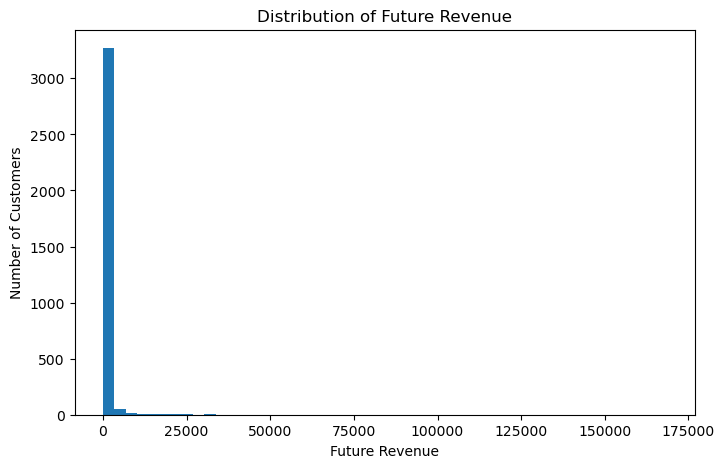

In [30]:
plt.figure(figsize=(8,5))
plt.hist(clv_df["Future_Revenue"], bins=50)
plt.title("Distribution of Future Revenue")
plt.xlabel("Future Revenue")
plt.ylabel("Number of Customers")
plt.show()

### Observation

The target variable is expected to be highly right-skewed. Most customers generate low future revenue, while a small number contribute significantly more.

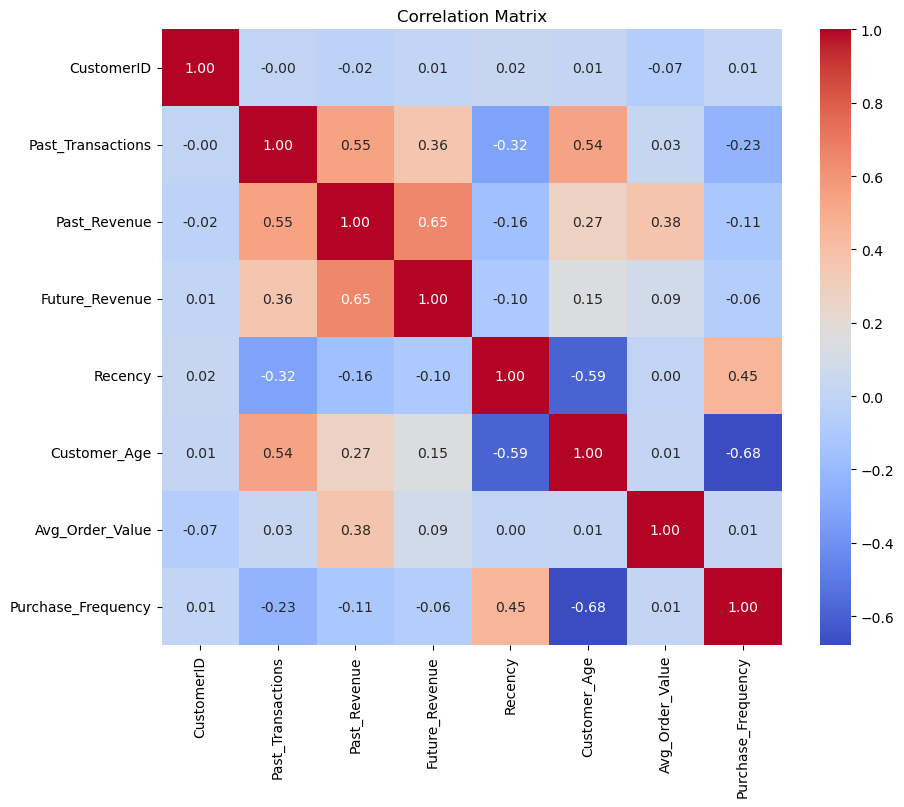

In [31]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(
    clv_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Observation

The correlation matrix helps identify which historical customer behavior features have the strongest relationship with future revenue.

This provides intuition about which variables may be the most informative for the prediction model.

# Model Building

The engineered customer-level dataset is now split into training and testing sets.

The model is trained on historical customer behavior and evaluated on unseen data to measure its ability to generalize.

In [32]:
X = clv_df.drop(columns=["CustomerID", "Future_Revenue"])
y = clv_df["Future_Revenue"]

print(X.shape)
print(y.shape)

(3370, 6)
(3370,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 2696
Testing samples : 674


## Random Forest Regression

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions.

It is chosen because it can capture non-linear relationships, is robust to outliers, and generally performs well on structured tabular datasets such as customer transaction data.

In [34]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [35]:
y_pred = rf_model.predict(X_test)

y_pred[:10]

array([ 578.6754,   69.4311,  217.469 ,  169.8936, 2212.261 ,  855.1755,
        479.7829, 1696.8109,  329.5638,  867.5193])

In [36]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 3))

MAE : 1090.92
RMSE: 7722.96
R² Score: 0.084


In [37]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Past_Revenue,0.796854
4,Avg_Order_Value,0.083311
5,Purchase_Frequency,0.036940
2,Recency,0.034353
3,Customer_Age,0.025715
0,Past_Transactions,0.022826


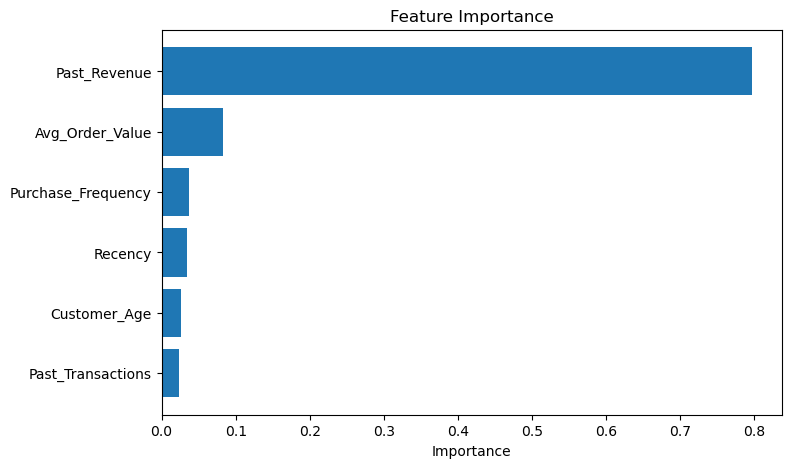

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

In [39]:
import numpy as np

clv_df["Future_Revenue_Log"] = np.log1p(clv_df["Future_Revenue"])

clv_df[["Future_Revenue", "Future_Revenue_Log"]].head()

,Future_Revenue,Future_Revenue_Log
0,0.00,0.000000
1,1519.14,7.326558
2,310.00,5.739793
3,0.00,0.000000
4,944.23,6.851428


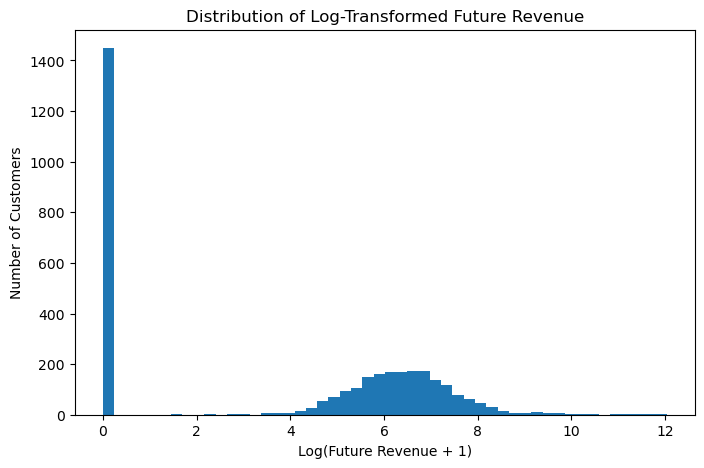

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(clv_df["Future_Revenue_Log"], bins=50)
plt.title("Distribution of Log-Transformed Future Revenue")
plt.xlabel("Log(Future Revenue + 1)")
plt.ylabel("Number of Customers")
plt.show()

## Baseline Model: Linear Regression

Linear Regression is used as a baseline model. It helps us understand whether more complex models such as Random Forest or Gradient Boosting provide significant performance improvements.

In [41]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(lr_mae,2))
print("RMSE:", round(lr_rmse,2))
print("R² :", round(lr_r2,3))

Linear Regression Results
-------------------------
MAE : 1033.48
RMSE: 7268.84
R² : 0.188


## Gradient Boosting Regressor

Gradient Boosting builds decision trees sequentially, where each new tree attempts to reduce the errors made by the previous trees.

It often performs well on structured tabular datasets.

In [43]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [44]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", round(gb_mae,2))
print("RMSE:", round(gb_rmse,2))
print("R² :", round(gb_r2,3))

Gradient Boosting Results
-------------------------
MAE : 1087.69
RMSE: 7947.68
R² : 0.029


## Model Comparison

The performance of three regression algorithms is compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The best-performing model will be selected for further improvement.

In [45]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        lr_mae,
        mae,
        gb_mae
    ],
    "RMSE": [
        lr_rmse,
        rmse,
        gb_rmse
    ],
    "R2 Score": [
        lr_r2,
        r2,
        gb_r2
    ]
})

results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1033.477245,7268.842581,0.188169
1,Random Forest,1090.921912,7722.959327,0.083563
2,Gradient Boosting,1087.686377,7947.677283,0.029456


## Hyperparameter Tuning

Hyperparameter tuning is performed to identify the optimal Random Forest configuration.

RandomizedSearchCV is used to efficiently search different parameter combinations and improve the model's predictive performance.

In [46]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [47]:
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 20, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2')

In [48]:
print(random_search.best_params_)

{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5}


In [49]:
best_rf = random_search.best_estimator_

best_pred = best_rf.predict(X_test)

In [50]:
best_mae = mean_absolute_error(y_test, best_pred)
best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
best_r2 = r2_score(y_test, best_pred)

print("Tuned Random Forest")
print("-------------------")
print("MAE :", round(best_mae,2))
print("RMSE:", round(best_rmse,2))
print("R² :", round(best_r2,3))

Tuned Random Forest
-------------------
MAE : 1049.67
RMSE: 7549.55
R² : 0.124


In [51]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Past_Revenue,0.868207
4,Avg_Order_Value,0.055055
2,Recency,0.031099
0,Past_Transactions,0.016494
5,Purchase_Frequency,0.016014
3,Customer_Age,0.013132


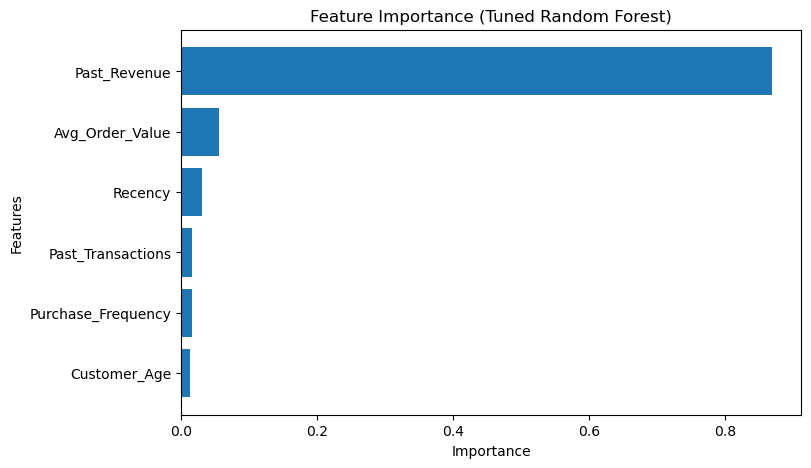

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance (Tuned Random Forest)")

plt.show()

## Feature Importance Analysis

The Random Forest model provides feature importance scores that indicate which customer characteristics contribute most to predicting future customer lifetime value.

Features with higher importance have a greater influence on the model's predictions.

# Business Recommendations

Based on the model and exploratory analysis, the following recommendations can help improve customer retention and revenue:

- Identify customers with high predicted lifetime value and target them with loyalty programs.
- Re-engage customers with high historical spending but increasing recency using personalized offers.
- Encourage repeat purchases among customers with moderate purchase frequency.
- Allocate marketing budgets toward customers with higher predicted future revenue to maximize return on investment.

# Conclusion

In this project, an end-to-end Customer Lifetime Value prediction pipeline was developed.

The workflow included:

- Data cleaning and preprocessing
- Customer-level feature engineering
- Exploratory data analysis
- Model training using Linear Regression, Random Forest, and Gradient Boosting
- Hyperparameter tuning using RandomizedSearchCV
- Model interpretation using feature importance

The tuned Random Forest model achieved the best performance among the evaluated models.

This project demonstrates how machine learning can help businesses identify valuable customers, improve retention strategies, and support data-driven marketing decisions.